In [ ]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "07-application-agent-framework/retrieval-rag/embeddings-lab/notebooks")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# 03 · The geometry of embedding spaces
Four phenomena you will meet in production: **anisotropy**, **hubness**, the
**Johnson–Lindenstrauss** guarantee behind dimension cuts, and why **SVD was
the original Matryoshka**. *Primer §3, §7–8.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

art = np.load("../artifacts/word_vectors.npz", allow_pickle=True)  # run 01 first
W_sgns, C = art["W_sgns"], art["C"]
vocab = [str(w) for w in art["vocab"]]; w2i = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

def normed(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

# a small labeled probe: word pairs that are related (same topic) vs unrelated
TOPICS = [
    ["king","queen","prince","princess","palace","throne","crown"],
    ["dog","cat","horse","cow","sheep","bird","fish","barks","farm"],
    ["bread","cheese","soup","rice","tea","coffee","kitchen","bowl"],
    ["hammer","saw","rope","wheel","anvil","workshop","iron"],
    ["rain","snow","wind","storm","cloud","frost","winter"],
]
related, unrelated = [], []
for ti, t in enumerate(TOPICS):
    for i in range(len(t)):
        for j in range(i + 1, len(t)):
            related.append((t[i], t[j]))
    other = TOPICS[(ti + 1) % len(TOPICS)]
    for a in t[:4]:
        for b in other[:4]:
            unrelated.append((a, b))

def auc_related(W):
    """P(cos(related pair) > cos(unrelated pair)) — 1.0 is perfect."""
    Z = normed(W)
    cs = lambda pairs: np.array([Z[w2i[a]] @ Z[w2i[b]] for a, b in pairs])
    r, u = cs(related), cs(unrelated)
    return float((r[:, None] > u[None, :]).mean())

## Anisotropy: "everything is similar to everything"
Compare the mean cosine of *random* word pairs. Raw count vectors share one
giant frequency direction; SGNS is better; centering + dropping the top
principal component (*All-but-the-Top*, Mu & Viswanath 2018) fixes the rest at
essentially no cost to the related-vs-unrelated signal.

In [2]:
def mean_random_cos(W, m=4000):
    Z = normed(W)
    i, j = rng.integers(0, len(Z), m), rng.integers(0, len(Z), m)
    keep = i != j
    return float((Z[i[keep]] * Z[j[keep]]).sum(1).mean())

def all_but_the_top(X, n_pc=2):
    Xc = X - X.mean(0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Xc - (Xc @ Vt[:n_pc].T) @ Vt[:n_pc]

candidates = {
    "raw counts": C.astype(float),
    "SGNS": W_sgns,
    "SGNS + all-but-the-top": all_but_the_top(W_sgns, 1),
}
print(f"{'space':>24} | mean random cos | related-vs-unrelated AUC")
for name, W in candidates.items():
    print(f"{name:>24} | {mean_random_cos(W):15.3f} | {auc_related(W):.3f}")

                   space | mean random cos | related-vs-unrelated AUC
              raw counts |           0.859 | 0.985
                    SGNS |           0.318 | 1.000
  SGNS + all-but-the-top |          -0.002 | 0.993


Anisotropy is why a similarity of 0.7 from one model means nothing in another:
the *baseline* cosine differs. Thresholds must be re-tuned per model (§7).

## Hubness: a few points are everyone's neighbour
Count how often each word appears in others' top-10 (`N₁₀`). A long right tail
= hubs. **CSLS** (Conneau et al. 2018) rescales similarity by each point's
local neighbourhood density and flattens the tail.

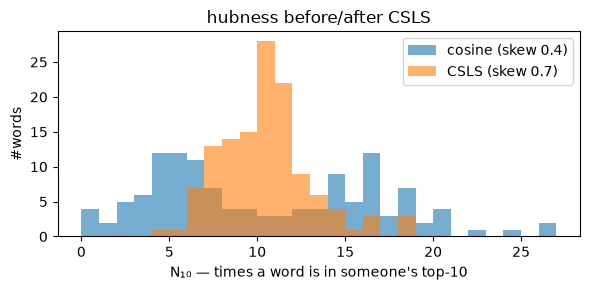

biggest hubs under cosine: ['guards', 'watches', 'loves', 'rules', 'said']


In [3]:
def knn_occurrences(S, k=10):
    np.fill_diagonal(S, -np.inf)
    top = np.argsort(-S, axis=1)[:, :k]
    return np.bincount(top.ravel(), minlength=len(S))

def csls(S, k=10):
    np.fill_diagonal(S, -np.inf)
    r_row = np.sort(S, axis=1)[:, -k:].mean(1)
    return 2 * S - r_row[None, :] - r_row[:, None]

Z = normed(W_sgns)
S = Z @ Z.T
occ_cos = knn_occurrences(S.copy())
occ_csls = knn_occurrences(csls(S.copy()))
skew = lambda x: float(((x - x.mean()) ** 3).mean() / x.std() ** 3)

plt.figure(figsize=(6, 3))
bins = np.arange(0, max(occ_cos.max(), occ_csls.max()) + 2)
plt.hist(occ_cos, bins=bins, alpha=0.6, label=f"cosine (skew {skew(occ_cos):.1f})")
plt.hist(occ_csls, bins=bins, alpha=0.6, label=f"CSLS (skew {skew(occ_csls):.1f})")
plt.xlabel("N₁₀ — times a word is in someone's top-10"); plt.ylabel("#words")
plt.legend(); plt.title("hubness before/after CSLS"); plt.tight_layout(); plt.show()
hubs = [vocab[i] for i in np.argsort(-occ_cos)[:5]]
print("biggest hubs under cosine:", hubs)

## Johnson–Lindenstrauss: why dimension cuts are cheap
A *random* projection to `k = O(log n / ε²)` dims preserves all pairwise
distances within (1±ε). No training, no data-dependence — the floor that PCA
and Matryoshka improve on.

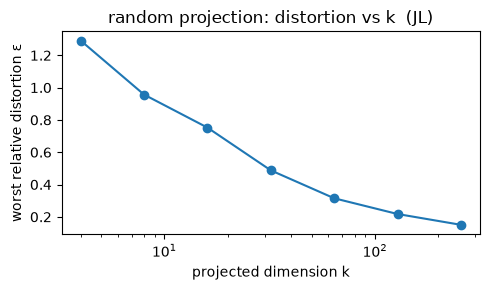

In [4]:
N, D = 1500, 384
X = rng.normal(size=(N, D)) + rng.normal(size=(1, D)) * 0.5
i, j = rng.integers(0, N, 3000), rng.integers(0, N, 3000)
keep = i != j; i, j = i[keep], j[keep]
d_full = np.linalg.norm(X[i] - X[j], axis=1)

ks = [4, 8, 16, 32, 64, 128, 256]
worst = []
for k in ks:
    R = rng.normal(size=(D, k)) / np.sqrt(k)
    d_proj = np.linalg.norm(X[i] @ R - X[j] @ R, axis=1)
    worst.append(np.abs(d_proj / d_full - 1).max())
plt.figure(figsize=(5, 3))
plt.semilogx(ks, worst, "o-")
plt.xlabel("projected dimension k"); plt.ylabel("worst relative distortion ε")
plt.title("random projection: distortion vs k  (JL)")
plt.tight_layout(); plt.show()

## SVD is the original Matryoshka
SVD orders dimensions by singular value, so a *prefix* of the vector is the
best low-rank view. Compare neighbour-list overlap when truncating to the
first `k` dims vs a random `k`-dim subset. (MRL trains modern models to have
exactly this property — §5.)

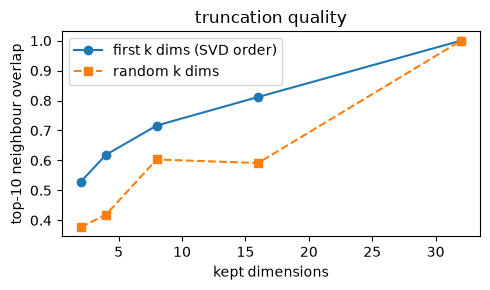

In [5]:
Wf = art["W_svd"]
Zf = normed(Wf)
gold = np.argsort(-(Zf @ Zf.T) + np.eye(V) * -9, axis=1)[:, :10]

def overlap(Wk):
    Zk = normed(Wk)
    top = np.argsort(-(Zk @ Zk.T) + np.eye(V) * -9, axis=1)[:, :10]
    return float(np.mean([len(set(a) & set(b)) / 10 for a, b in zip(top, gold)]))

ks = [2, 4, 8, 16, 32]
pref = [overlap(Wf[:, :k]) for k in ks]
rand = [overlap(Wf[:, rng.choice(Wf.shape[1], k, replace=False)]) for k in ks]
plt.figure(figsize=(5, 3))
plt.plot(ks, pref, "o-", label="first k dims (SVD order)")
plt.plot(ks, rand, "s--", label="random k dims")
plt.xlabel("kept dimensions"); plt.ylabel("top-10 neighbour overlap")
plt.legend(); plt.title("truncation quality"); plt.tight_layout(); plt.show()

**Takeaways.** (1) Measure anisotropy before trusting cosines. (2) If the same
chunks surface for every query, suspect hubness — CSLS/centering help. (3) JL
explains why 256 dims is usually plenty. (4) Dimension order matters: trained
(MRL) or spectral (SVD) prefixes ≫ arbitrary subsets. → `exercises/ex03.ipynb`.